# XGBoost Baseline

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from xgboost import XGBRegressor

### Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
test_ids = test_df['id'].copy()

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
train_df.head()

Train shape: (630000, 13)
Test shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


### Preprocess

In [3]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality',
                    'study_method', 'facility_rating', 'exam_difficulty']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

feature_cols = [c for c in train_df.columns if c not in ['id', 'exam_score']]

X = train_df[feature_cols]
y = train_df['exam_score']
X_submission = test_df[feature_cols]

print(f'Features: {feature_cols}')

Features: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


### Train/Validation Split

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Validation: {X_val.shape}')

Train: (504000, 11), Validation: (126000, 11)


### Train

In [5]:
model = XGBRegressor(
    n_estimators=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [ ]:
# feature analysis
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.to_string(index=False))

### Evaluate

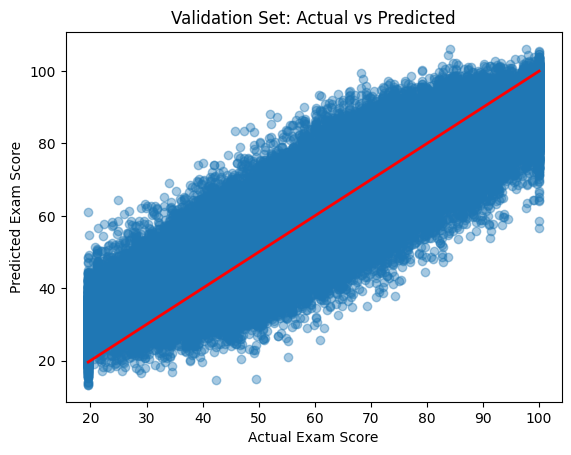

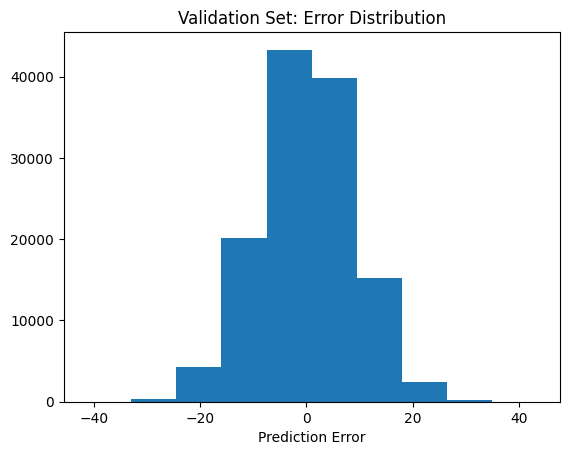

Metrics saved to ../metrics/xgboost_baseline_metrics.csv


,MAE,MSE,RMSE,R2
0,7.082934,79.256165,8.902593,0.777149


In [6]:
y_val_pred = model.predict(X_val)

# Actual vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Validation Set: Actual vs Predicted')
plt.show()

# Error distribution
plt.hist(y_val - y_val_pred)
plt.xlabel('Prediction Error')
plt.title('Validation Set: Error Distribution')
plt.show()

# Metrics
pd.set_option('float_format', '{:f}'.format)
res_metrics = pd.DataFrame({
    'MAE': [metrics.mean_absolute_error(y_val, y_val_pred)],
    'MSE': [metrics.mean_squared_error(y_val, y_val_pred)],
    'RMSE': [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
    'R2': [metrics.r2_score(y_val, y_val_pred)],
})
res_metrics.to_csv('../metrics/xgboost_baseline_metrics.csv', index=False)
print('Metrics saved to ../metrics/xgboost_baseline_metrics.csv')
res_metrics

### Generate Submission

In [7]:
y_submission_pred = model.predict(X_submission)
submission = pd.DataFrame({'id': test_ids, 'exam_score': y_submission_pred})
submission.to_csv('../submission/xgboost_baseline_submission.csv', index=False)
print('Submission saved to ../submission/xgboost_baseline_submission.csv')
submission

Submission saved to ../submission/xgboost_baseline_submission.csv


,id,exam_score
0,630000,65.889771
1,630001,70.261124
2,630002,89.106483
3,630003,61.907436
4,630004,49.485416
...,...,...
269995,899995,59.473946
269996,899996,41.018921
269997,899997,88.555222
269998,899998,53.492142


In [8]:
# Save model
joblib.dump(model, '../models/xgboost_baseline.pkl')
print('Model saved to ../models/xgboost_baseline.pkl')

Model saved to ../models/xgboost_baseline.pkl
